# Drowsiness Pipeline (CSV-Only)

This notebook starts from already extracted features.
It does **not** use raw video dataset paths.


In [1]:
import os
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import label_binarize
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_recall_fscore_support, roc_auc_score, roc_curve, auc

sns.set_theme(style='whitegrid')


In [2]:
# Update these paths if your CSVs are in another folder.
features_progress_path = 'features_progress.csv'

print('features_progress_path exists:', os.path.exists(features_progress_path))



features_progress_path exists: True


In [3]:
features_df = pd.read_csv(features_progress_path)
print('Loaded frame-level rows:', len(features_df))
display(features_df.head())


Loaded frame-level rows: 235706


,subject,label,frame,EAR,MAR,pitch,yaw,video_path
0,20,Low Vigilance,30,0.265168,0.093651,476.009454,748.818403,/kaggle/input/datasets/rishab260/uta-reallife-...
1,20,Low Vigilance,40,0.193316,0.003777,458.795161,741.967654,/kaggle/input/datasets/rishab260/uta-reallife-...
2,20,Low Vigilance,50,0.209924,0.021052,417.269697,681.898819,/kaggle/input/datasets/rishab260/uta-reallife-...
3,20,Low Vigilance,60,0.200726,0.034570,373.262642,636.804523,/kaggle/input/datasets/rishab260/uta-reallife-...
4,20,Low Vigilance,70,0.189407,0.006242,360.013889,629.407658,/kaggle/input/datasets/rishab260/uta-reallife-...


In [4]:
# Subject-wise normalization using Alert frames as baseline
numeric_cols = ['EAR', 'MAR', 'pitch', 'yaw']

baseline = (
    features_df[features_df['label'] == 'Alert']
    .groupby('subject')[numeric_cols]
    .mean()
)


def normalize(row):
    subject = row['subject']
    if subject in baseline.index:
        row['EAR_dev'] = row['EAR'] - baseline.loc[subject, 'EAR']
        row['MAR_dev'] = row['MAR'] - baseline.loc[subject, 'MAR']
    else:
        row['EAR_dev'] = row['EAR']
        row['MAR_dev'] = row['MAR']
    return row

features_df = features_df.apply(normalize, axis=1)
print('Normalized rows:', len(features_df))
display(features_df.head())


Normalized rows: 235706


,subject,label,frame,EAR,MAR,pitch,yaw,video_path,EAR_dev,MAR_dev
0,20,Low Vigilance,30,0.265168,0.093651,476.009454,748.818403,/kaggle/input/datasets/rishab260/uta-reallife-...,0.011799,0.084260
1,20,Low Vigilance,40,0.193316,0.003777,458.795161,741.967654,/kaggle/input/datasets/rishab260/uta-reallife-...,-0.060053,-0.005614
2,20,Low Vigilance,50,0.209924,0.021052,417.269697,681.898819,/kaggle/input/datasets/rishab260/uta-reallife-...,-0.043445,0.011661
3,20,Low Vigilance,60,0.200726,0.034570,373.262642,636.804523,/kaggle/input/datasets/rishab260/uta-reallife-...,-0.052643,0.025179
4,20,Low Vigilance,70,0.189407,0.006242,360.013889,629.407658,/kaggle/input/datasets/rishab260/uta-reallife-...,-0.063962,-0.003149


In [5]:
# features_df already contains the normalized values in memory.
print('Normalized rows:', len(features_df))
display(features_df.head())


Normalized rows: 235706


,subject,label,frame,EAR,MAR,pitch,yaw,video_path,EAR_dev,MAR_dev
0,20,Low Vigilance,30,0.265168,0.093651,476.009454,748.818403,/kaggle/input/datasets/rishab260/uta-reallife-...,0.011799,0.084260
1,20,Low Vigilance,40,0.193316,0.003777,458.795161,741.967654,/kaggle/input/datasets/rishab260/uta-reallife-...,-0.060053,-0.005614
2,20,Low Vigilance,50,0.209924,0.021052,417.269697,681.898819,/kaggle/input/datasets/rishab260/uta-reallife-...,-0.043445,0.011661
3,20,Low Vigilance,60,0.200726,0.034570,373.262642,636.804523,/kaggle/input/datasets/rishab260/uta-reallife-...,-0.052643,0.025179
4,20,Low Vigilance,70,0.189407,0.006242,360.013889,629.407658,/kaggle/input/datasets/rishab260/uta-reallife-...,-0.063962,-0.003149


In [6]:
window_size = 15
windows = []

for subject in features_df['subject'].unique():
    sub_df = features_df[features_df['subject'] == subject].copy()
    sub_df = sub_df.sort_values(['video_path', 'frame'])

    for video_path in sub_df['video_path'].unique():
        vid_df = sub_df[sub_df['video_path'] == video_path]

        for i in range(len(vid_df) - window_size):
            chunk = vid_df.iloc[i:i + window_size]

            windows.append({
                'subject': subject,
                'video_path': video_path,
                'label': chunk['label'].iloc[0],
                'EAR_mean': chunk['EAR'].mean(),
                'EAR_std': chunk['EAR'].std(),
                'EAR_min': chunk['EAR'].min(),
                'MAR_mean': chunk['MAR'].mean(),
                'MAR_max': chunk['MAR'].max(),
                'pitch_mean': chunk['pitch'].mean(),
                'yaw_mean': chunk['yaw'].mean(),
                'EAR_dev_mean': chunk['EAR_dev'].mean(),
                'MAR_dev_mean': chunk['MAR_dev'].mean()
            })

window_df = pd.DataFrame(windows)

print('Window rows:', len(window_df))
display(window_df.head())


Window rows: 233591


,subject,video_path,label,EAR_mean,EAR_std,EAR_min,MAR_mean,MAR_max,pitch_mean,yaw_mean,EAR_dev_mean,MAR_dev_mean
0,20,/kaggle/input/datasets/rishab260/uta-reallife-...,Alert,0.237036,0.037249,0.137103,0.036132,0.199047,370.103525,635.342636,-0.016333,0.026740
1,20,/kaggle/input/datasets/rishab260/uta-reallife-...,Alert,0.247254,0.045480,0.137103,0.035163,0.199047,332.952045,581.059837,-0.006115,0.025772
2,20,/kaggle/input/datasets/rishab260/uta-reallife-...,Alert,0.252945,0.050826,0.137103,0.029647,0.199047,327.099773,572.753631,-0.000425,0.020256
3,20,/kaggle/input/datasets/rishab260/uta-reallife-...,Alert,0.257431,0.055144,0.137103,0.030483,0.199047,314.021163,556.392134,0.004062,0.021092
4,20,/kaggle/input/datasets/rishab260/uta-reallife-...,Alert,0.256823,0.055100,0.137103,0.018152,0.042090,303.104617,530.404469,0.003454,0.008761


In [7]:
# Train model from window-level features
le = LabelEncoder()
window_df['y'] = le.fit_transform(window_df['label'])

drop_cols = ['label', 'y', 'subject', 'video_path']
X = window_df.drop(drop_cols, axis=1)
y = window_df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train, y_train)
pred = model.predict(X_test)
pred_proba = model.predict_proba(X_test)

accuracy = accuracy_score(y_test, pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, pred, average='weighted', zero_division=0)
macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(y_test, pred, average='macro', zero_division=0)
y_test_bin = label_binarize(y_test, classes=range(len(le.classes_)))
roc_auc_macro = roc_auc_score(y_test_bin, pred_proba, multi_class='ovr', average='macro')
roc_auc_weighted = roc_auc_score(y_test_bin, pred_proba, multi_class='ovr', average='weighted')

print('Accuracy:', accuracy)
print('Weighted Precision:', precision)
print('Weighted Recall:', recall)
print('Weighted F1-score:', f1)
print('Macro Precision:', macro_precision)
print('Macro Recall:', macro_recall)
print('Macro F1-score:', macro_f1)
print('ROC-AUC Macro (OVR):', roc_auc_macro)
print('ROC-AUC Weighted (OVR):', roc_auc_weighted)
print('Classification Report:')
print(classification_report(y_test, pred, target_names=le.classes_))
print('Confusion Matrix:')
print(confusion_matrix(y_test, pred))


Accuracy: 0.9962756052141527
Weighted Precision: 0.996276208766491
Weighted Recall: 0.9962756052141527
Weighted F1-score: 0.9962754682617914
Macro Precision: 0.9962734897520539
Macro Recall: 0.9962714769755903
Macro F1-score: 0.996272045871193
ROC-AUC Macro (OVR): 0.9999625447513494
ROC-AUC Weighted (OVR): 0.999962542998437
Classification Report:
               precision    recall  f1-score   support

        Alert       1.00      1.00      1.00     15619
       Drowsy       1.00      1.00      1.00     15693
Low Vigilance       1.00      1.00      1.00     15407

     accuracy                           1.00     46719
    macro avg       1.00      1.00      1.00     46719
 weighted avg       1.00      1.00      1.00     46719

Confusion Matrix:
[[15581    13    25]
 [   26 15630    37]
 [   41    32 15334]]


,Accuracy,Weighted Precision,Weighted Recall,Weighted F1-score,Macro Precision,Macro Recall,Macro F1-score,ROC-AUC Macro,ROC-AUC Weighted
0,0.996276,0.996276,0.996276,0.996275,0.996273,0.996271,0.996272,0.999963,0.999963


C:\Users\PMLS\AppData\Local\Temp\ipykernel_9096\2863380041.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metric_plot, x='Metric', y='Score', ax=axes[1], palette='viridis')


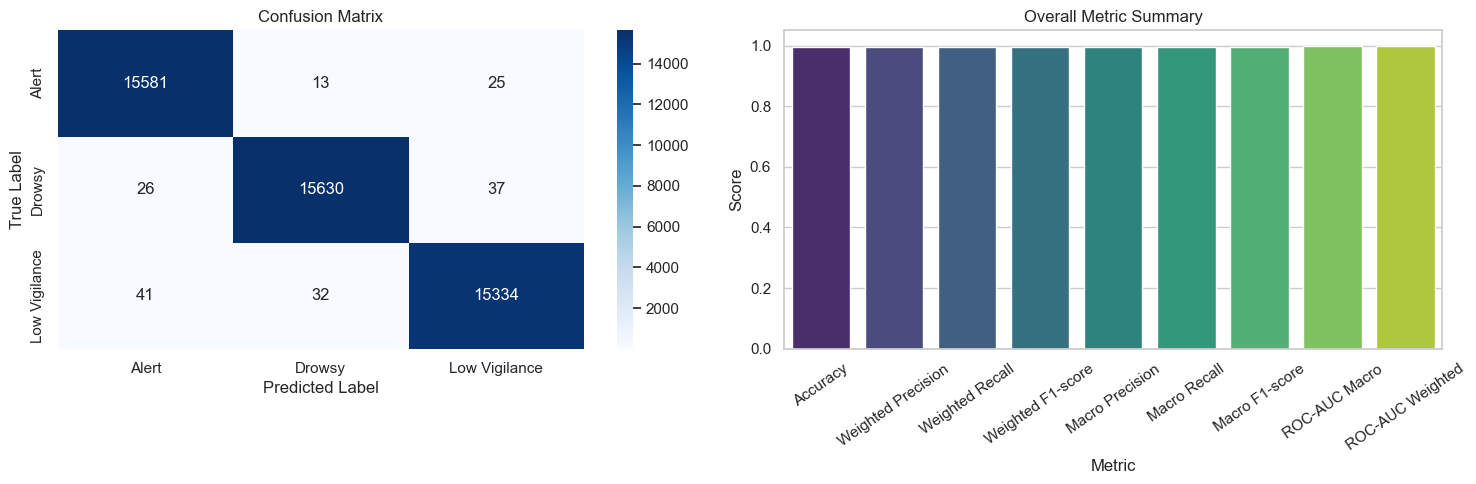

,precision,recall,f1-score,support
Alert,0.995718,0.997567,0.996642,15619.000000
Drowsy,0.997129,0.995985,0.996557,15693.000000
Low Vigilance,0.995973,0.995262,0.995617,15407.000000
accuracy,0.996276,0.996276,0.996276,0.996276
macro avg,0.996273,0.996271,0.996272,46719.000000
weighted avg,0.996276,0.996276,0.996275,46719.000000


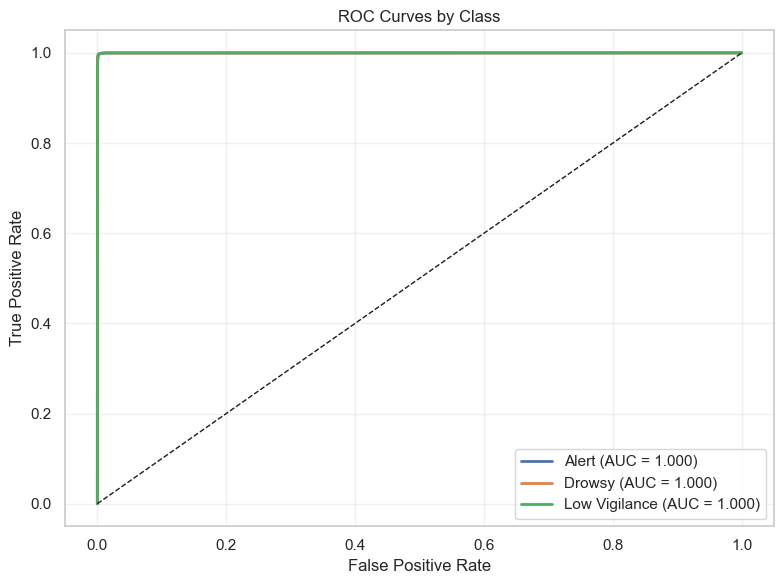

,Feature,Importance
6,yaw_mean,0.197072
5,pitch_mean,0.194703
7,EAR_dev_mean,0.149622
0,EAR_mean,0.108052
8,MAR_dev_mean,0.095184
4,MAR_max,0.090455
2,EAR_min,0.064911
3,MAR_mean,0.058387
1,EAR_std,0.041615


C:\Users\PMLS\AppData\Local\Temp\ipykernel_9096\2863380041.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='mako')


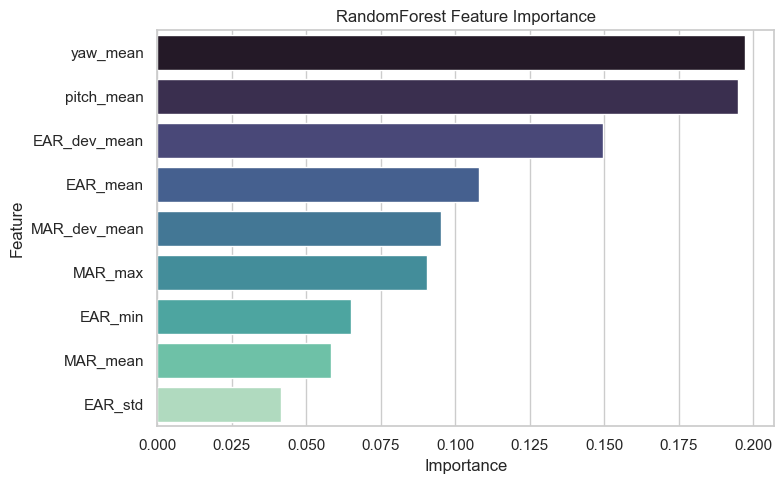

In [8]:
# Evaluation plots and summary metrics
cm = confusion_matrix(y_test, pred)
report = classification_report(y_test, pred, target_names=le.classes_, output_dict=True, zero_division=0)

metrics_summary = pd.DataFrame([{
    'Accuracy': accuracy,
    'Weighted Precision': precision,
    'Weighted Recall': recall,
    'Weighted F1-score': f1,
    'Macro Precision': macro_precision,
    'Macro Recall': macro_recall,
    'Macro F1-score': macro_f1,
    'ROC-AUC Macro': roc_auc_macro,
    'ROC-AUC Weighted': roc_auc_weighted
}])
display(metrics_summary)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

metric_plot = metrics_summary.T.reset_index()
metric_plot.columns = ['Metric', 'Score']
sns.barplot(data=metric_plot, x='Metric', y='Score', ax=axes[1], palette='viridis')
axes[1].set_title('Overall Metric Summary')
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()

report_df = pd.DataFrame(report).T
display(report_df)

# One-vs-rest ROC curves
fig, ax = plt.subplots(figsize=(8, 6))
roc_auc_by_class = {}
for idx, class_name in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, idx], pred_proba[:, idx])
    roc_auc_by_class[class_name] = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2, label=f'{class_name} (AUC = {roc_auc_by_class[class_name]:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_title('ROC Curves by Class')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Feature importance for RandomForest
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)
display(feature_importance)

plt.figure(figsize=(8, 5))
sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='mako')
plt.title('RandomForest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [9]:
# Save training artifacts
output_dir = 'random-outputs'
os.makedirs(output_dir, exist_ok=True)

joblib.dump(model, os.path.join(output_dir, 'random_forest_model.pkl'))
joblib.dump(le, os.path.join(output_dir, 'label_encoder.pkl'))
joblib.dump(list(X.columns), os.path.join(output_dir, 'feature_columns.pkl'))

print(f'Saved in {output_dir}: random_forest_model.pkl, label_encoder.pkl, feature_columns.pkl')


Saved in random-outputs: random_forest_model.pkl, label_encoder.pkl, feature_columns.pkl


In [10]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Regularized RandomForest with hyperparameters to reduce overfitting
tuned_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

# K-fold cross-validation for more robust evaluation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(tuned_model, X, y, cv=skf, scoring='f1_weighted')
cv_accuracy = cross_val_score(tuned_model, X, y, cv=skf, scoring='accuracy')
cv_roc_auc = cross_val_score(tuned_model, X, y, cv=skf, scoring='roc_auc_ovr_weighted')

print('='*60)
print('Tuned RandomForest with Regularization + K-Fold CV')
print('='*60)
print(f'CV Accuracy scores: {cv_accuracy}')
print(f'Mean CV Accuracy: {cv_accuracy.mean():.4f} (+/- {cv_accuracy.std():.4f})')
print()
print(f'CV F1 (Weighted) scores: {cv_scores}')
print(f'Mean CV F1 (Weighted): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')
print()
print(f'CV ROC-AUC (Weighted) scores: {cv_roc_auc}')
print(f'Mean CV ROC-AUC (Weighted): {cv_roc_auc.mean():.4f} (+/- {cv_roc_auc.std():.4f})')
print()

# Train final model on full training data
tuned_model.fit(X_train, y_train)
tuned_pred = tuned_model.predict(X_test)
tuned_pred_proba = tuned_model.predict_proba(X_test)

tuned_accuracy = accuracy_score(y_test, tuned_pred)
tuned_precision, tuned_recall, tuned_f1, _ = precision_recall_fscore_support(y_test, tuned_pred, average='weighted', zero_division=0)
tuned_macro_precision, tuned_macro_recall, tuned_macro_f1, _ = precision_recall_fscore_support(y_test, tuned_pred, average='macro', zero_division=0)
y_test_bin_tuned = label_binarize(y_test, classes=range(len(le.classes_)))
tuned_roc_auc_macro = roc_auc_score(y_test_bin_tuned, tuned_pred_proba, multi_class='ovr', average='macro')
tuned_roc_auc_weighted = roc_auc_score(y_test_bin_tuned, tuned_pred_proba, multi_class='ovr', average='weighted')

print('='*60)
print('Tuned Model Test Set Performance')
print('='*60)
print(f'Test Accuracy: {tuned_accuracy:.4f}')
print(f'Test Weighted F1: {tuned_f1:.4f}')
print(f'Test Macro F1: {tuned_macro_f1:.4f}')
print(f'Test ROC-AUC Weighted: {tuned_roc_auc_weighted:.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, tuned_pred, target_names=le.classes_))
print()

# Compare original vs tuned
comparison = pd.DataFrame([{
    'Model': 'Original (Unregularized)',
    'Test Accuracy': accuracy,
    'Test F1 (Weighted)': f1,
    'Test ROC-AUC': roc_auc_weighted,
    'CV F1 Mean': 'N/A',
    'CV F1 Std': 'N/A'
}, {
    'Model': 'Tuned (Regularized)',
    'Test Accuracy': tuned_accuracy,
    'Test F1 (Weighted)': tuned_f1,
    'Test ROC-AUC': tuned_roc_auc_weighted,
    'CV F1 Mean': f'{cv_scores.mean():.4f}',
    'CV F1 Std': f'{cv_scores.std():.4f}'
}])
print('Model Comparison:')
display(comparison)

# Save tuned model artifacts
tuned_output_dir = 'tuned-random-output'
os.makedirs(tuned_output_dir, exist_ok=True)

joblib.dump(tuned_model, os.path.join(tuned_output_dir, 'tuned_random_forest_model.pkl'))
joblib.dump(le, os.path.join(tuned_output_dir, 'label_encoder.pkl'))
joblib.dump(list(X.columns), os.path.join(tuned_output_dir, 'feature_columns.pkl'))

print(f'\nSaved tuned model in {tuned_output_dir}: tuned_random_forest_model.pkl, label_encoder.pkl, feature_columns.pkl')

Tuned RandomForest with Regularization + K-Fold CV
CV Accuracy scores: [0.85121685 0.85470268 0.85887666 0.85594418 0.85356822]
Mean CV Accuracy: 0.8549 (+/- 0.0025)

CV F1 (Weighted) scores: [0.85145216 0.85500542 0.859102   0.8562247  0.85377751]
Mean CV F1 (Weighted): 0.8551 (+/- 0.0025)

CV ROC-AUC (Weighted) scores: [0.95862046 0.95991526 0.96214619 0.95953447 0.95897753]
Mean CV ROC-AUC (Weighted): 0.9598 (+/- 0.0012)

Tuned Model Test Set Performance
Test Accuracy: 0.8539
Test Weighted F1: 0.8541
Test Macro F1: 0.8540
Test ROC-AUC Weighted: 0.9602

Classification Report:
               precision    recall  f1-score   support

        Alert       0.83      0.90      0.86     15619
       Drowsy       0.92      0.83      0.87     15693
Low Vigilance       0.83      0.84      0.83     15407

     accuracy                           0.85     46719
    macro avg       0.86      0.85      0.85     46719
 weighted avg       0.86      0.85      0.85     46719


Model Comparison:


,Model,Test Accuracy,Test F1 (Weighted),Test ROC-AUC,CV F1 Mean,CV F1 Std
0,Original (Unregularized),0.996276,0.996275,0.999963,N/A,N/A
1,Tuned (Regularized),0.853914,0.854125,0.960183,0.8551,0.0025



Saved tuned model in tuned-random-output: tuned_random_forest_model.pkl, label_encoder.pkl, feature_columns.pkl


Tuned Model Visualizations & Analysis


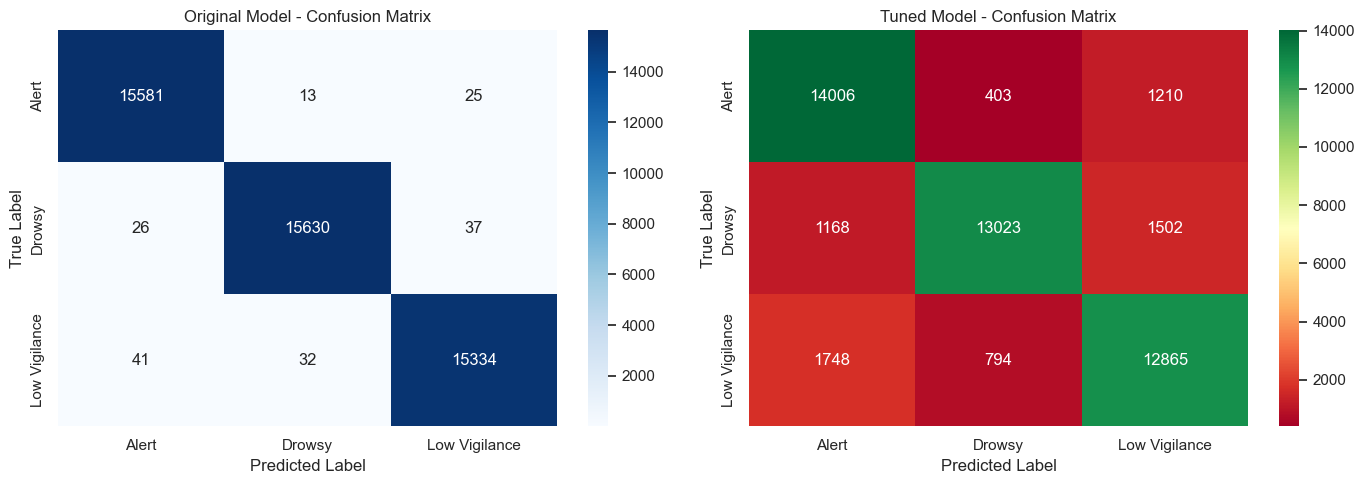

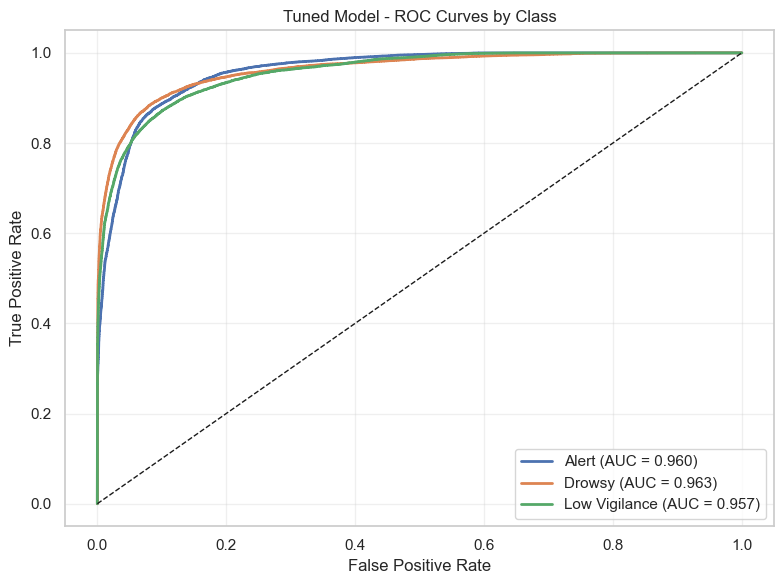

,Feature,Importance
7,EAR_dev_mean,0.242389
6,yaw_mean,0.192523
5,pitch_mean,0.192152
0,EAR_mean,0.103932
8,MAR_dev_mean,0.085629
4,MAR_max,0.061652
2,EAR_min,0.054707
3,MAR_mean,0.043489
1,EAR_std,0.023526


C:\Users\PMLS\AppData\Local\Temp\ipykernel_9096\352864848.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='mako', ax=axes[0])
C:\Users\PMLS\AppData\Local\Temp\ipykernel_9096\352864848.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tuned_feature_importance, x='Importance', y='Feature', palette='viridis', ax=axes[1])


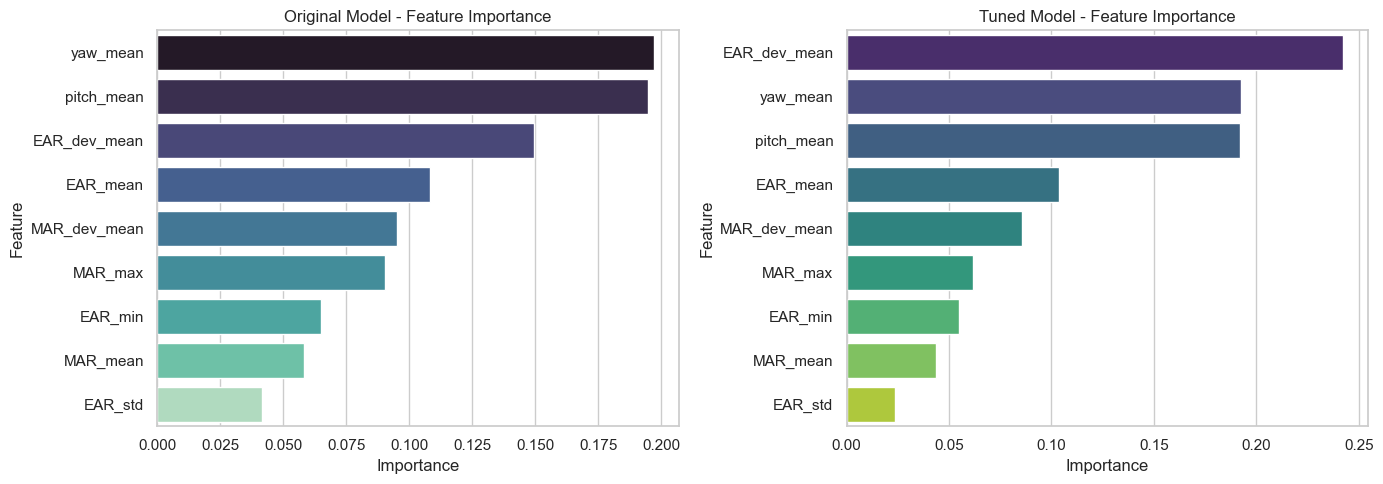

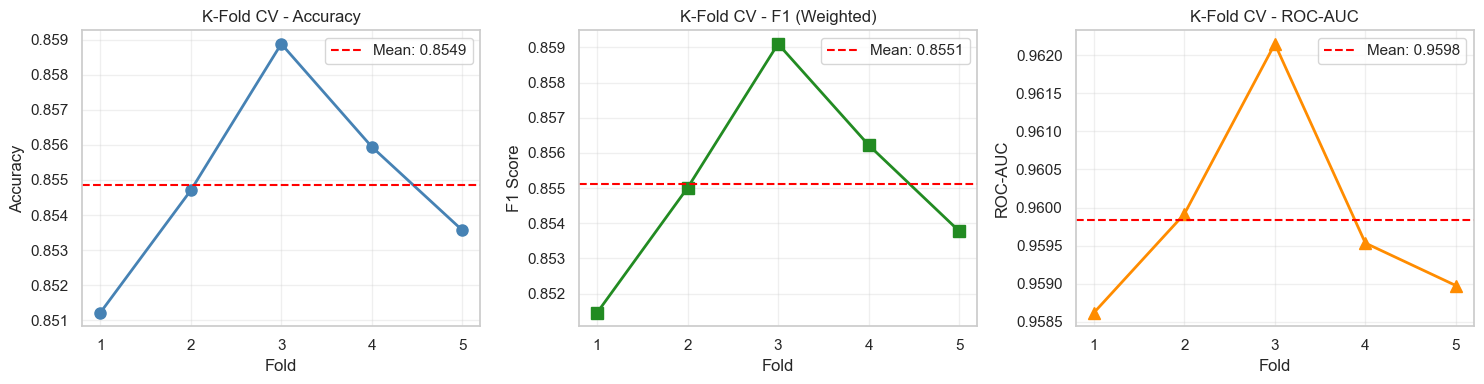


Full Metrics Comparison (Original vs Tuned):


,Metric,Original,Tuned,Difference
0,Accuracy,0.9963,0.8539,-0.1424
1,Weighted Precision,0.9963,0.8567,-0.1396
2,Weighted Recall,0.9963,0.8539,-0.1424
3,Weighted F1-score,0.9963,0.8541,-0.1422
4,Macro Precision,0.9963,0.8565,-0.1398
5,Macro Recall,0.9963,0.8539,-0.1424
6,Macro F1-score,0.9963,0.8540,-0.1423
7,ROC-AUC Macro,1.0000,0.9602,-0.0398
8,ROC-AUC Weighted,1.0000,0.9602,-0.0398


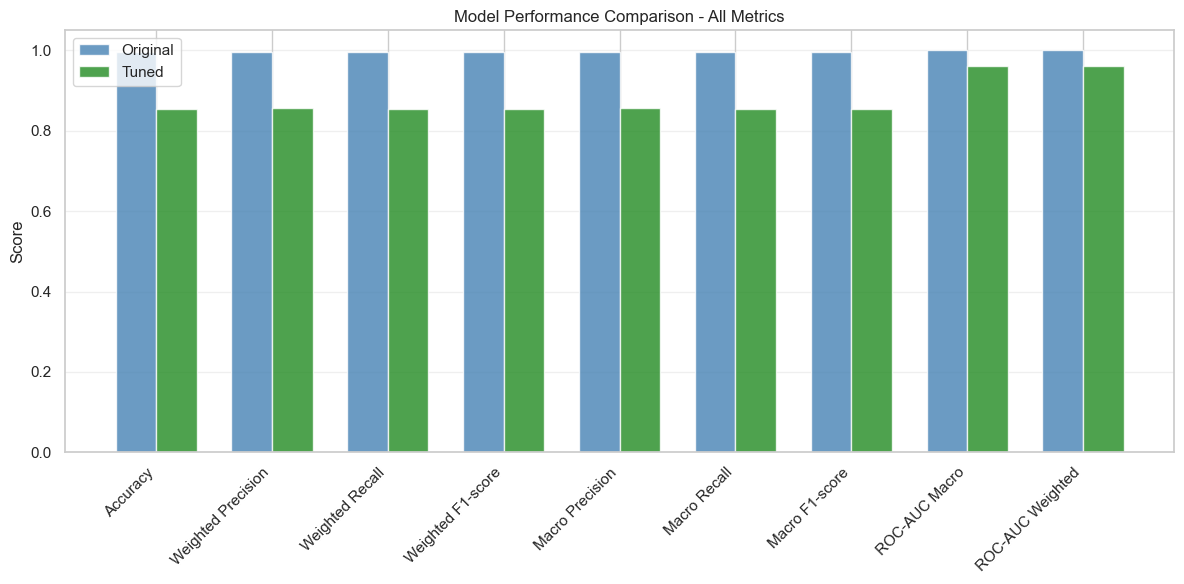


Per-Class Performance Comparison:


,Class,Original_F1,Tuned_F1,Original_Precision,Tuned_Precision,Original_Recall,Tuned_Recall
0,Alert,0.996642,0.860822,0.995718,0.827680,0.997567,0.896728
1,Drowsy,0.996557,0.870725,0.997129,0.915823,0.995985,0.829860
2,Low Vigilance,0.995617,0.830429,0.995973,0.825897,0.995262,0.835010


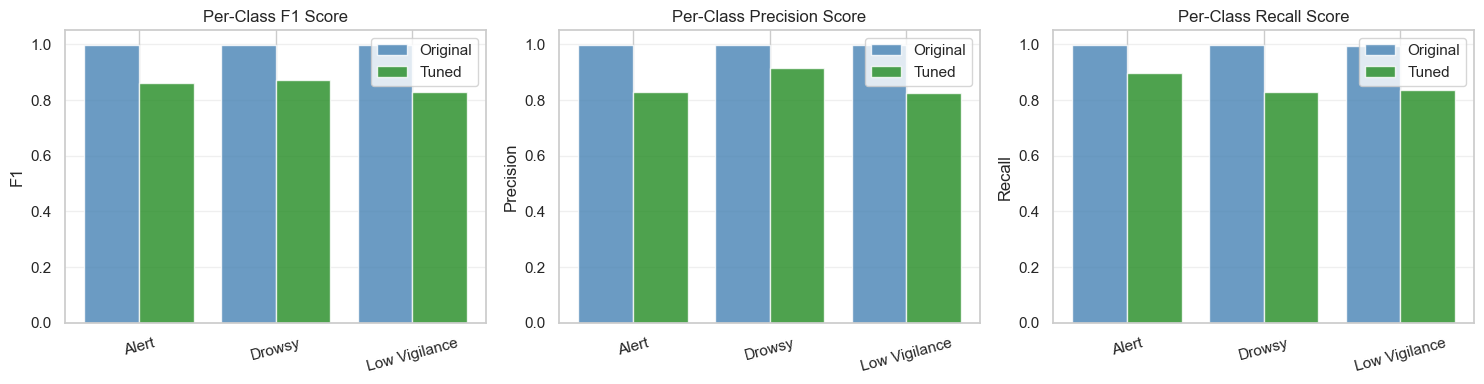


Visualization Complete!


In [11]:
# Visualizations for Tuned Model
print('='*60)
print('Tuned Model Visualizations & Analysis')
print('='*60)

# Compute tuned model metrics
tuned_cm = confusion_matrix(y_test, tuned_pred)
tuned_report = classification_report(y_test, tuned_pred, target_names=le.classes_, output_dict=True, zero_division=0)

# Plot 1: Confusion Matrix Comparison (Original vs Tuned)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Original Model - Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(tuned_cm, annot=True, fmt='d', cmap='RdYlGn', xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title('Tuned Model - Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

# Plot 2: ROC Curves for Tuned Model
fig, ax = plt.subplots(figsize=(8, 6))
tuned_roc_auc_by_class = {}
for idx, class_name in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin_tuned[:, idx], tuned_pred_proba[:, idx])
    tuned_roc_auc_by_class[class_name] = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2, label=f'{class_name} (AUC = {tuned_roc_auc_by_class[class_name]:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_title('Tuned Model - ROC Curves by Class')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 3: Feature Importance for Tuned Model
tuned_feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': tuned_model.feature_importances_
}).sort_values('Importance', ascending=False)
display(tuned_feature_importance)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original model feature importance
sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='mako', ax=axes[0])
axes[0].set_title('Original Model - Feature Importance')
axes[0].set_xlabel('Importance')

# Tuned model feature importance
sns.barplot(data=tuned_feature_importance, x='Importance', y='Feature', palette='viridis', ax=axes[1])
axes[1].set_title('Tuned Model - Feature Importance')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

# Plot 4: K-Fold Cross-Validation Performance
cv_results = pd.DataFrame({
    'Fold': [1, 2, 3, 4, 5],
    'Accuracy': cv_accuracy,
    'F1 (Weighted)': cv_scores,
    'ROC-AUC': cv_roc_auc
})

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(cv_results['Fold'], cv_results['Accuracy'], marker='o', linewidth=2, markersize=8, color='steelblue')
axes[0].axhline(cv_accuracy.mean(), color='red', linestyle='--', label=f'Mean: {cv_accuracy.mean():.4f}')
axes[0].set_title('K-Fold CV - Accuracy')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(cv_results['Fold'], cv_results['F1 (Weighted)'], marker='s', linewidth=2, markersize=8, color='forestgreen')
axes[1].axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean: {cv_scores.mean():.4f}')
axes[1].set_title('K-Fold CV - F1 (Weighted)')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('F1 Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(cv_results['Fold'], cv_results['ROC-AUC'], marker='^', linewidth=2, markersize=8, color='darkorange')
axes[2].axhline(cv_roc_auc.mean(), color='red', linestyle='--', label=f'Mean: {cv_roc_auc.mean():.4f}')
axes[2].set_title('K-Fold CV - ROC-AUC')
axes[2].set_xlabel('Fold')
axes[2].set_ylabel('ROC-AUC')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot 5: Metrics Comparison (All metrics side-by-side)
tuned_metrics_summary = pd.DataFrame([{
    'Accuracy': tuned_accuracy,
    'Weighted Precision': tuned_precision,
    'Weighted Recall': tuned_recall,
    'Weighted F1-score': tuned_f1,
    'Macro Precision': tuned_macro_precision,
    'Macro Recall': tuned_macro_recall,
    'Macro F1-score': tuned_macro_f1,
    'ROC-AUC Macro': tuned_roc_auc_macro,
    'ROC-AUC Weighted': tuned_roc_auc_weighted
}])

comparison_full = pd.DataFrame({
    'Metric': metrics_summary.columns,
    'Original': metrics_summary.iloc[0].values,
    'Tuned': tuned_metrics_summary.iloc[0].values
})
comparison_full['Difference'] = comparison_full['Tuned'] - comparison_full['Original']
comparison_full = comparison_full.round(4)
print('\nFull Metrics Comparison (Original vs Tuned):')
display(comparison_full)

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(comparison_full))
width = 0.35
ax.bar([i - width/2 for i in x], comparison_full['Original'], width, label='Original', alpha=0.8, color='steelblue')
ax.bar([i + width/2 for i in x], comparison_full['Tuned'], width, label='Tuned', alpha=0.8, color='forestgreen')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison - All Metrics')
ax.set_xticks(x)
ax.set_xticklabels(comparison_full['Metric'], rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Plot 6: Per-Class Performance
per_class_metrics = pd.DataFrame([
    {
        'Class': le.classes_[0],
        'Original_F1': report[le.classes_[0]]['f1-score'],
        'Tuned_F1': tuned_report[le.classes_[0]]['f1-score'],
        'Original_Precision': report[le.classes_[0]]['precision'],
        'Tuned_Precision': tuned_report[le.classes_[0]]['precision'],
        'Original_Recall': report[le.classes_[0]]['recall'],
        'Tuned_Recall': tuned_report[le.classes_[0]]['recall']
    },
    {
        'Class': le.classes_[1],
        'Original_F1': report[le.classes_[1]]['f1-score'],
        'Tuned_F1': tuned_report[le.classes_[1]]['f1-score'],
        'Original_Precision': report[le.classes_[1]]['precision'],
        'Tuned_Precision': tuned_report[le.classes_[1]]['precision'],
        'Original_Recall': report[le.classes_[1]]['recall'],
        'Tuned_Recall': tuned_report[le.classes_[1]]['recall']
    },
    {
        'Class': le.classes_[2],
        'Original_F1': report[le.classes_[2]]['f1-score'],
        'Tuned_F1': tuned_report[le.classes_[2]]['f1-score'],
        'Original_Precision': report[le.classes_[2]]['precision'],
        'Tuned_Precision': tuned_report[le.classes_[2]]['precision'],
        'Original_Recall': report[le.classes_[2]]['recall'],
        'Tuned_Recall': tuned_report[le.classes_[2]]['recall']
    }
])
print('\nPer-Class Performance Comparison:')
display(per_class_metrics)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, metric in enumerate(['F1', 'Precision', 'Recall']):
    x_pos = range(len(per_class_metrics))
    orig_col = f'Original_{metric}'
    tuned_col = f'Tuned_{metric}'
    
    axes[i].bar([p - 0.2 for p in x_pos], per_class_metrics[orig_col], 0.4, label='Original', alpha=0.8, color='steelblue')
    axes[i].bar([p + 0.2 for p in x_pos], per_class_metrics[tuned_col], 0.4, label='Tuned', alpha=0.8, color='forestgreen')
    axes[i].set_ylabel(metric)
    axes[i].set_title(f'Per-Class {metric} Score')
    axes[i].set_xticks(x_pos)
    axes[i].set_xticklabels(per_class_metrics['Class'], rotation=15)
    axes[i].legend()
    axes[i].set_ylim(0, 1.05)
    axes[i].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print('\n' + '='*60)
print('Visualization Complete!')
print('='*60)

XGBoost Ensemble Model Implementation

K-Fold Cross-Validation Results:
CV Accuracy scores: [0.93546523 0.94042981 0.93608459 0.93400831 0.93709063]
Mean CV Accuracy: 0.9366 (+/- 0.0022)

CV F1 (Weighted) scores: [0.93545832 0.94042334 0.93605772 0.93399112 0.93707962]
Mean CV F1 (Weighted): 0.9366 (+/- 0.0022)

CV ROC-AUC (Weighted) scores: [0.99156745 0.99241994 0.9920265  0.99127506 0.99168553]
Mean CV ROC-AUC (Weighted): 0.9918 (+/- 0.0004)

XGBoost Test Set Performance
Test Accuracy: 0.9372
Test Weighted F1: 0.9372
Test Macro F1: 0.9371
Test ROC-AUC Weighted: 0.9919

Classification Report:
               precision    recall  f1-score   support

        Alert       0.93      0.95      0.94     15619
       Drowsy       0.95      0.94      0.95     15693
Low Vigilance       0.93      0.92      0.92     15407

     accuracy                           0.94     46719
    macro avg       0.94      0.94      0.94     46719
 weighted avg       0.94      0.94      0.94     46719


Three-Mod

,Model,Test Accuracy,Test F1,Test ROC-AUC,CV F1 Mean,Generalization Gap
0,Original (RF Unregularized),0.996276,0.996275,0.999963,N/A,N/A
1,Tuned (RF Regularized),0.853914,0.854125,0.960183,0.8551,0.0010
2,XGBoost Ensemble,0.937199,0.937174,0.991927,0.9366,0.0006



Generating visualizations...


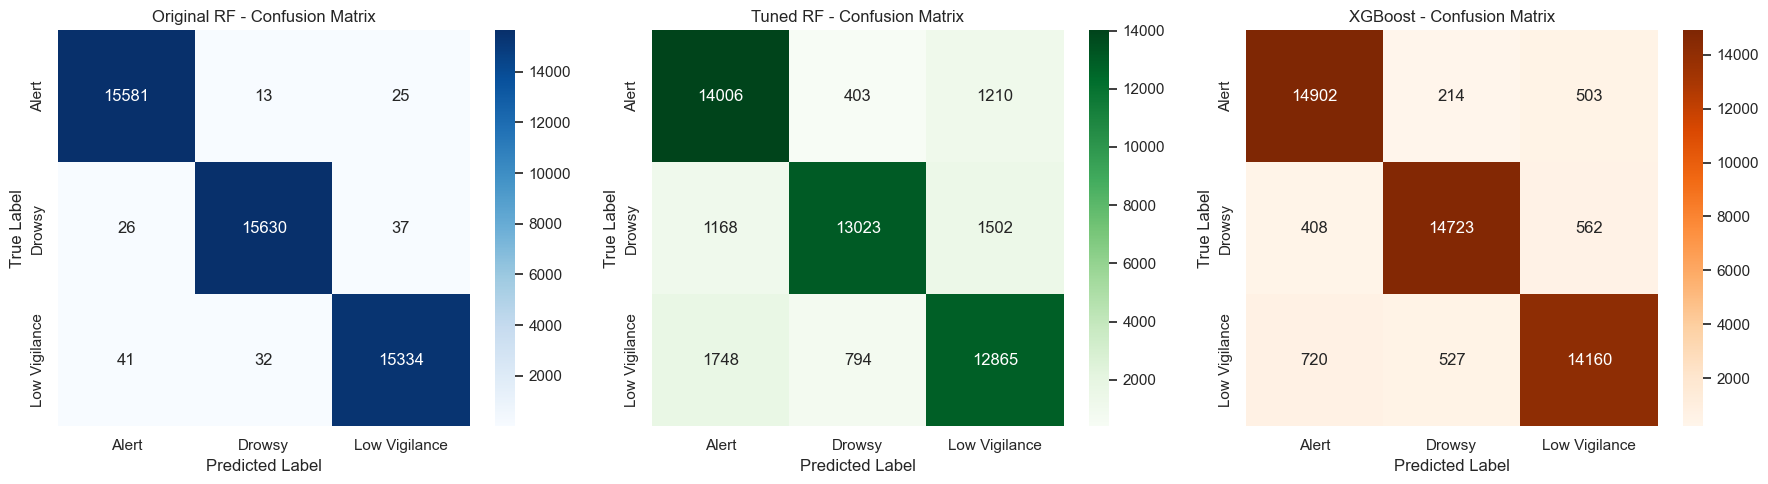

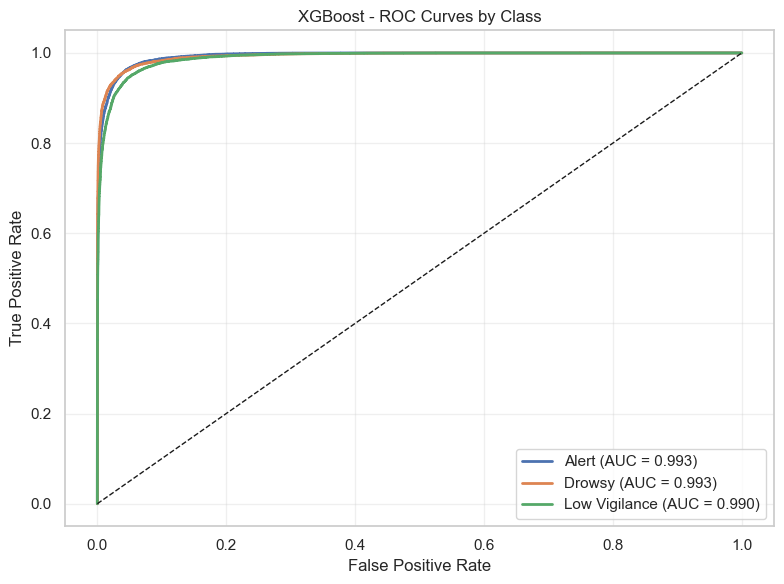

,Feature,Importance
7,EAR_dev_mean,0.277185
5,pitch_mean,0.130928
6,yaw_mean,0.128955
8,MAR_dev_mean,0.108755
3,MAR_mean,0.084594
0,EAR_mean,0.081279
4,MAR_max,0.075506
2,EAR_min,0.071791
1,EAR_std,0.041007


C:\Users\PMLS\AppData\Local\Temp\ipykernel_9096\1759561851.py:143: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x='Importance', y='Feature', palette=['mako', 'viridis', 'plasma'][idx], ax=axes[idx])
C:\Users\PMLS\AppData\Local\Temp\ipykernel_9096\1759561851.py:143: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x='Importance', y='Feature', palette=['mako', 'viridis', 'plasma'][idx], ax=axes[idx])
C:\Users\PMLS\AppData\Local\Temp\ipykernel_9096\1759561851.py:143: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=f

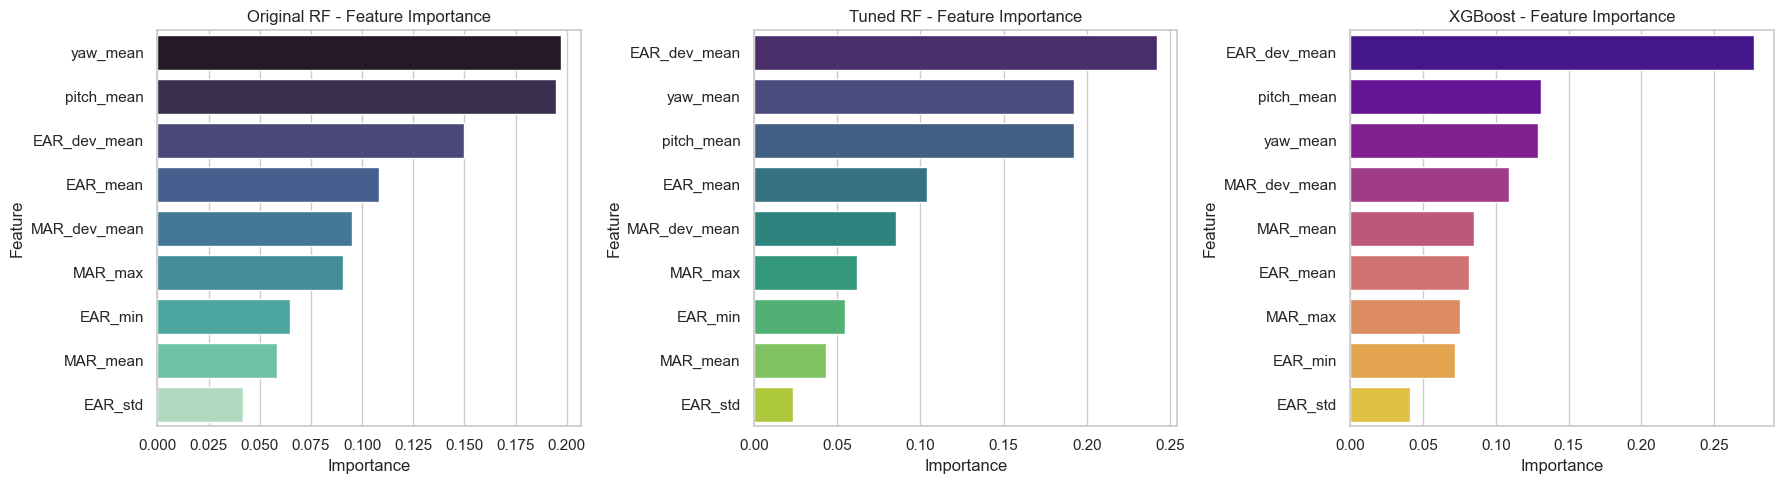

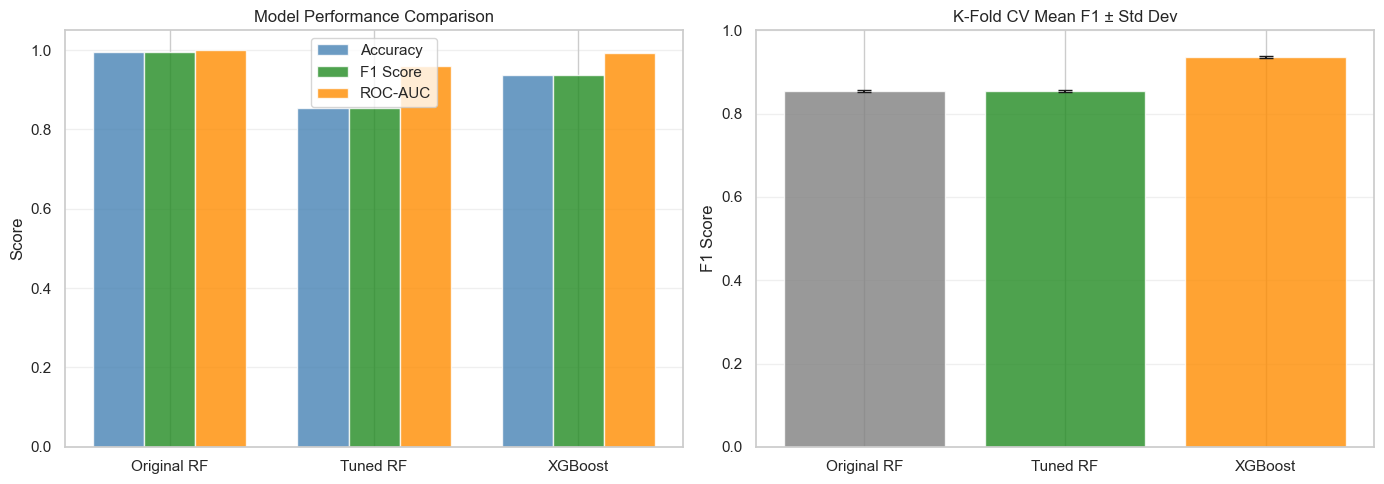


✓ Saved XGBoost model in xgboost-output:
  - xgboost_model.pkl
  - label_encoder.pkl
  - feature_columns.pkl
  - model_comparison.csv
  - feature_importance.csv



In [16]:
# XGBoost Ensemble Model with K-Fold Cross-Validation
from xgboost import XGBClassifier

print('='*60)
print('XGBoost Ensemble Model Implementation')
print('='*60)

# XGBoost with optimized hyperparameters for better generalization
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0,
    reg_alpha=0.5,  # L1 regularization
    reg_lambda=1.0,  # L2 regularization
    random_state=42,
    tree_method='hist',
    n_jobs=-1,
    verbosity=0,
    use_label_encoder=False,
    eval_metric='logloss'
)

# K-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
xgb_cv_accuracy = cross_val_score(xgb_model, X, y, cv=skf, scoring='accuracy')
xgb_cv_f1 = cross_val_score(xgb_model, X, y, cv=skf, scoring='f1_weighted')
xgb_cv_roc_auc = cross_val_score(xgb_model, X, y, cv=skf, scoring='roc_auc_ovr_weighted')

print('\nK-Fold Cross-Validation Results:')
print(f'CV Accuracy scores: {xgb_cv_accuracy}')
print(f'Mean CV Accuracy: {xgb_cv_accuracy.mean():.4f} (+/- {xgb_cv_accuracy.std():.4f})')
print()
print(f'CV F1 (Weighted) scores: {xgb_cv_f1}')
print(f'Mean CV F1 (Weighted): {xgb_cv_f1.mean():.4f} (+/- {xgb_cv_f1.std():.4f})')
print()
print(f'CV ROC-AUC (Weighted) scores: {xgb_cv_roc_auc}')
print(f'Mean CV ROC-AUC (Weighted): {xgb_cv_roc_auc.mean():.4f} (+/- {xgb_cv_roc_auc.std():.4f})')

# Train final model on full training data
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_pred_proba = xgb_model.predict_proba(X_test)

# Evaluation metrics
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision, xgb_recall, xgb_f1, _ = precision_recall_fscore_support(y_test, xgb_pred, average='weighted', zero_division=0)
xgb_macro_precision, xgb_macro_recall, xgb_macro_f1, _ = precision_recall_fscore_support(y_test, xgb_pred, average='macro', zero_division=0)
y_test_bin_xgb = label_binarize(y_test, classes=range(len(le.classes_)))
xgb_roc_auc_macro = roc_auc_score(y_test_bin_xgb, xgb_pred_proba, multi_class='ovr', average='macro')
xgb_roc_auc_weighted = roc_auc_score(y_test_bin_xgb, xgb_pred_proba, multi_class='ovr', average='weighted')

print('\n' + '='*60)
print('XGBoost Test Set Performance')
print('='*60)
print(f'Test Accuracy: {xgb_accuracy:.4f}')
print(f'Test Weighted F1: {xgb_f1:.4f}')
print(f'Test Macro F1: {xgb_macro_f1:.4f}')
print(f'Test ROC-AUC Weighted: {xgb_roc_auc_weighted:.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, xgb_pred, target_names=le.classes_))

# Three-model comparison
model_comparison = pd.DataFrame([{
    'Model': 'Original (RF Unregularized)',
    'Test Accuracy': accuracy,
    'Test F1': f1,
    'Test ROC-AUC': roc_auc_weighted,
    'CV F1 Mean': 'N/A',
    'Generalization Gap': 'N/A'
}, {
    'Model': 'Tuned (RF Regularized)',
    'Test Accuracy': tuned_accuracy,
    'Test F1': tuned_f1,
    'Test ROC-AUC': tuned_roc_auc_weighted,
    'CV F1 Mean': f'{cv_scores.mean():.4f}',
    'Generalization Gap': f'{abs(tuned_f1 - cv_scores.mean()):.4f}'
}, {
    'Model': 'XGBoost Ensemble',
    'Test Accuracy': xgb_accuracy,
    'Test F1': xgb_f1,
    'Test ROC-AUC': xgb_roc_auc_weighted,
    'CV F1 Mean': f'{xgb_cv_f1.mean():.4f}',
    'Generalization Gap': f'{abs(xgb_f1 - xgb_cv_f1.mean()):.4f}'
}])

print('\n' + '='*60)
print('Three-Model Comparison:')
print('='*60)
display(model_comparison)

# Visualizations
print('\nGenerating visualizations...')

# Plot 1: Confusion Matrix for XGBoost
xgb_cm = confusion_matrix(y_test, xgb_pred)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm_list = [cm, tuned_cm, xgb_cm]
titles = ['Original RF', 'Tuned RF', 'XGBoost']
for idx, (cm_plot, title) in enumerate(zip(cm_list, titles)):
    sns.heatmap(cm_plot, annot=True, fmt='d', cmap=['Blues', 'Greens', 'Oranges'][idx], 
                xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[idx])
    axes[idx].set_title(f'{title} - Confusion Matrix')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')

plt.tight_layout()
plt.show()

# Plot 2: ROC Curves for XGBoost
fig, ax = plt.subplots(figsize=(8, 6))
xgb_roc_auc_by_class = {}
for idx, class_name in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin_xgb[:, idx], xgb_pred_proba[:, idx])
    xgb_roc_auc_by_class[class_name] = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2, label=f'{class_name} (AUC = {xgb_roc_auc_by_class[class_name]:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_title('XGBoost - ROC Curves by Class')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 3: Feature Importance for XGBoost
xgb_feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)
display(xgb_feature_importance)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

feature_dfs = [feature_importance, tuned_feature_importance, xgb_feature_importance]
model_names = ['Original RF', 'Tuned RF', 'XGBoost']
for idx, (feat_df, model_name) in enumerate(zip(feature_dfs, model_names)):
    sns.barplot(data=feat_df, x='Importance', y='Feature', palette=['mako', 'viridis', 'plasma'][idx], ax=axes[idx])
    axes[idx].set_title(f'{model_name} - Feature Importance')
    axes[idx].set_xlabel('Importance')

plt.tight_layout()
plt.show()

# Plot 4: Accuracy Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy and F1 comparison
models = ['Original RF', 'Tuned RF', 'XGBoost']
accuracies = [accuracy, tuned_accuracy, xgb_accuracy]
f1_scores = [f1, tuned_f1, xgb_f1]
roc_aucs = [roc_auc_weighted, tuned_roc_auc_weighted, xgb_roc_auc_weighted]

x_pos = range(len(models))
width = 0.25

axes[0].bar([p - width for p in x_pos], accuracies, width, label='Accuracy', alpha=0.8, color='steelblue')
axes[0].bar([p for p in x_pos], f1_scores, width, label='F1 Score', alpha=0.8, color='forestgreen')
axes[0].bar([p + width for p in x_pos], roc_aucs, width, label='ROC-AUC', alpha=0.8, color='darkorange')
axes[0].set_ylabel('Score')
axes[0].set_title('Model Performance Comparison')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(models)
axes[0].legend()
axes[0].set_ylim(0, 1.05)
axes[0].grid(True, alpha=0.3, axis='y')

# K-Fold CV Stability
axes[1].bar([0, 1, 2], [cv_scores.mean(), cv_scores.mean(), xgb_cv_f1.mean()], 
            yerr=[cv_scores.std(), cv_scores.std(), xgb_cv_f1.std()],
            capsize=5, alpha=0.8, color=['gray', 'forestgreen', 'darkorange'])
axes[1].set_ylabel('F1 Score')
axes[1].set_title('K-Fold CV Mean F1 ± Std Dev')
axes[1].set_xticks([0, 1, 2])
axes[1].set_xticklabels(['Original RF', 'Tuned RF', 'XGBoost'])
axes[1].set_ylim(0, 1.0)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Save XGBoost model artifacts
xgb_output_dir = 'xgboost-output'
os.makedirs(xgb_output_dir, exist_ok=True)

joblib.dump(xgb_model, os.path.join(xgb_output_dir, 'xgboost_model.pkl'))
joblib.dump(le, os.path.join(xgb_output_dir, 'label_encoder.pkl'))
joblib.dump(list(X.columns), os.path.join(xgb_output_dir, 'feature_columns.pkl'))

# Save model comparison results
model_comparison.to_csv(os.path.join(xgb_output_dir, 'model_comparison.csv'), index=False)
xgb_feature_importance.to_csv(os.path.join(xgb_output_dir, 'feature_importance.csv'), index=False)

print(f'\n✓ Saved XGBoost model in {xgb_output_dir}:')
print(f'  - xgboost_model.pkl')
print(f'  - label_encoder.pkl')
print(f'  - feature_columns.pkl')
print(f'  - model_comparison.csv')
print(f'  - feature_importance.csv')
print('\n' + '='*60)